# ============================================================
#   DecodeLabs – Project 2: Exploratory Data Analysis (EDA)
#   Dataset: E-Commerce Orders (1200 rows × 14 columns)
# ============================================================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

── Style ────────────────────────────────────────────────────


In [ ]:
plt.rcParams.update({
    'figure.facecolor': '#0b0f1a',
    'axes.facecolor':   '#111827',
    'axes.edgecolor':   '#1f2d44',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#8899aa',
    'ytick.color':      '#8899aa',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1f2d44',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})

CYAN   = '#00d4ff'
GREEN  = '#00ff88'
ORANGE = '#ff6b35'
RED    = '#ff3b5c'
YELLOW = '#ffd700'
TEXT_COLOR = '#e2e8f0' # Defined TEXT_COLOR
BAR_COLORS = [CYAN, GREEN, ORANGE, YELLOW, RED, '#aa88ff', '#ff88cc']

════════════════════════════════════════════════════════════
# 1.  LOAD & CLEAN
════════════════════════════════════════════════════════════

In [ ]:
df=pd.read_csv('/content/Dataset for Data Analytics 4(Sheet1).csv')

In [ ]:
df['Date']      = pd.to_datetime(df['Date'])
df['Year']      = df['Date'].dt.year
df['Month']     = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M')

In [ ]:
# Fill missing CouponCode
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

In [ ]:
print("=" * 55)
print("  DecodeLabs EDA – Project 2")
print("=" * 55)
df.head()


  DecodeLabs EDA – Project 2


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,YearMonth
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,2023-01
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,2024-08
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,2024-02
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,2023-10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,2025-05


════════════════════════════════════════════════════════════
# 2.  BASIC INFO
════════════════════════════════════════════════════════════

In [ ]:
print("\n📋 DATASET INFO")
print(f"  Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Date range   : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Missing vals : CouponCode only ({df['CouponCode'].eq('No Coupon').sum()} blanks filled)")


📋 DATASET INFO
  Shape        : 1200 rows × 17 columns
  Date range   : 2023-01-01 → 2025-06-30
  Missing vals : CouponCode only (309 blanks filled)


════════════════════════════════════════════════════════════
# 3.  DESCRIPTIVE STATISTICS
════════════════════════════════════════════════════════════

In [ ]:
print("\n📊 DESCRIPTIVE STATISTICS")
num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
print(df[num_cols].describe().round(2).to_string())


📊 DESCRIPTIVE STATISTICS
       Quantity  UnitPrice  ItemsInCart  TotalPrice
count   1200.00    1200.00      1200.00     1200.00
mean       2.95     356.41         5.48     1053.97
std        1.41     197.18         2.28      819.86
min        1.00      11.39         1.00       11.39
25%        2.00     186.06         4.00      410.52
50%        3.00     364.21         5.00      823.62
75%        4.00     521.57         7.00     1578.48
max        5.00     699.93        10.00     3456.40


════════════════════════════════════════════════════════════
# 4.  OUTLIER DETECTION – IQR Method
════════════════════════════════════════════════════════════

In [ ]:
print("\n🚨 OUTLIER DETECTION (IQR Method – TotalPrice)")
Q1  = df['TotalPrice'].quantile(0.25)
Q3  = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]
print(f"  IQR = {IQR:.2f}  |  Lower = {lower:.2f}  |  Upper = {upper:.2f}")
print(f"  Outliers found: {len(outliers)}")
print(outliers[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']].to_string(index=False))



🚨 OUTLIER DETECTION (IQR Method – TotalPrice)
  IQR = 1167.95  |  Lower = -1341.41  |  Upper = 3330.41
  Outliers found: 8
  OrderID Product  Quantity  UnitPrice  TotalPrice
ORD200107 Printer         5     670.75     3353.75
ORD200326  Laptop         5     670.48     3352.40
ORD200328  Tablet         5     674.04     3370.20
ORD200469   Chair         5     676.98     3384.90
ORD200632  Laptop         5     678.16     3390.80
ORD200789  Tablet         5     691.28     3456.40
ORD201065 Printer         5     666.80     3334.00
ORD201122 Monitor         5     678.19     3390.95



════════════════════════════════════════════════════════════
# 5.  CORRELATION
════════════════════════════════════════════════════════════

In [ ]:
print("\n🔗 PEARSON CORRELATION with TotalPrice")
for col in ['Quantity', 'UnitPrice', 'ItemsInCart']:
    r = df[col].corr(df['TotalPrice'])
    print(f"  {col:15s} → r = {r:.3f}")


🔗 PEARSON CORRELATION with TotalPrice
  Quantity        → r = 0.615
  UnitPrice       → r = 0.717
  ItemsInCart     → r = 0.393


════════════════════════════════════════════════════════════
# 6.  CATEGORY COUNTS
════════════════════════════════════════════════════════════

In [ ]:
print("\n📦 ORDER STATUS")
print(df['OrderStatus'].value_counts().to_string())

print("\n🛒 PRODUCT REVENUE")
rev = df.groupby('Product')['TotalPrice'].agg(['sum','mean','count'])
rev.columns = ['Total Revenue', 'Avg Order', 'Count']
print(rev.sort_values('Total Revenue', ascending=False).round(2).to_string())

print("\n📅 REVENUE BY YEAR")
print(df.groupby('Year')['TotalPrice'].sum().round(2).to_string())

print("\n📣 REFERRAL SOURCE")
print(df['ReferralSource'].value_counts().to_string())

print("\n💳 PAYMENT METHOD")
print(df['PaymentMethod'].value_counts().to_string())

print("\n🎟 COUPON USAGE")
print(df['CouponCode'].value_counts().to_string())


📦 ORDER STATUS
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231

🛒 PRODUCT REVENUE
         Total Revenue  Avg Order  Count
Product                                 
Chair        195620.11    1098.99    178
Printer      195612.61    1080.73    181
Laptop       192126.56    1110.56    173
Tablet       186568.95    1042.28    179
Monitor      175651.41    1077.62    163
Desk         167459.93     985.06    170
Phone        151722.39     972.58    156

📅 REVENUE BY YEAR
Year
2023    552643.24
2024    480235.87
2025    231882.85

📣 REFERRAL SOURCE
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222

💳 PAYMENT METHOD
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230

🎟 COUPON USAGE
CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286


════════════════════════════════════════════════════════════
# 7.  VISUALIZATIONS
════════════════════════════════════════════════════════════

## ① TotalPrice Distribution

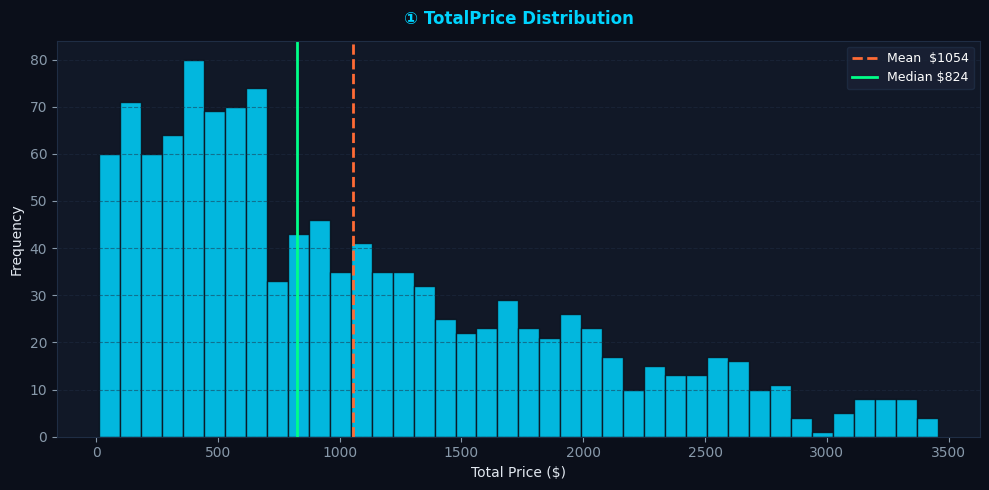

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax1, '① TotalPrice Distribution')

ax1.hist(df['TotalPrice'], bins=40, color=CYAN, edgecolor='#0b0f1a', alpha=0.85)
ax1.axvline(df['TotalPrice'].mean(),   color=ORANGE, lw=2, linestyle='--', label=f'Mean  ${df["TotalPrice"].mean():.0f}')
ax1.axvline(df['TotalPrice'].median(), color=GREEN,  lw=2, linestyle='-',  label=f'Median ${df["TotalPrice"].median():.0f}')
ax1.set_xlabel('Total Price ($)')
ax1.set_ylabel('Frequency')
ax1.legend(facecolor='#1a2235', edgecolor='#1f2d44', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.show()

## ② TotalPrice Boxplot by Product

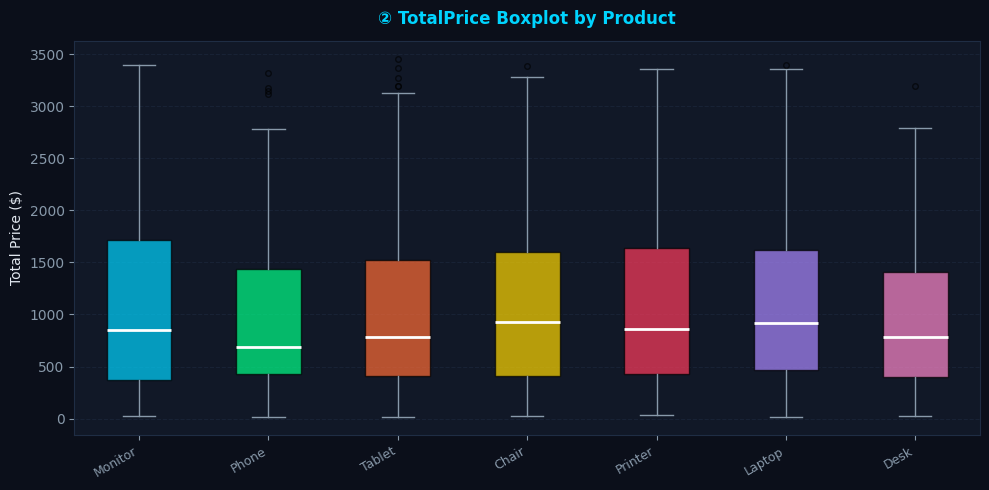

In [ ]:
fig, ax2 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax2, '② TotalPrice Boxplot by Product')

products   = df['Product'].unique()
colors_bp  = [CYAN, GREEN, ORANGE, YELLOW, RED, '#aa88ff', '#ff88cc']
bp = ax2.boxplot(
    [df[df['Product'] == p]['TotalPrice'].values for p in products],
    patch_artist=True, notch=False,
    medianprops=dict(color='white', lw=2),
    whiskerprops=dict(color='#8899aa'),
    capprops=dict(color='#8899aa'),
    flierprops=dict(marker='o', color=RED, markersize=4, alpha=0.6)
)
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xticklabels(products, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Total Price ($)')

plt.tight_layout()
plt.show()

## ③ Order Status Distribution

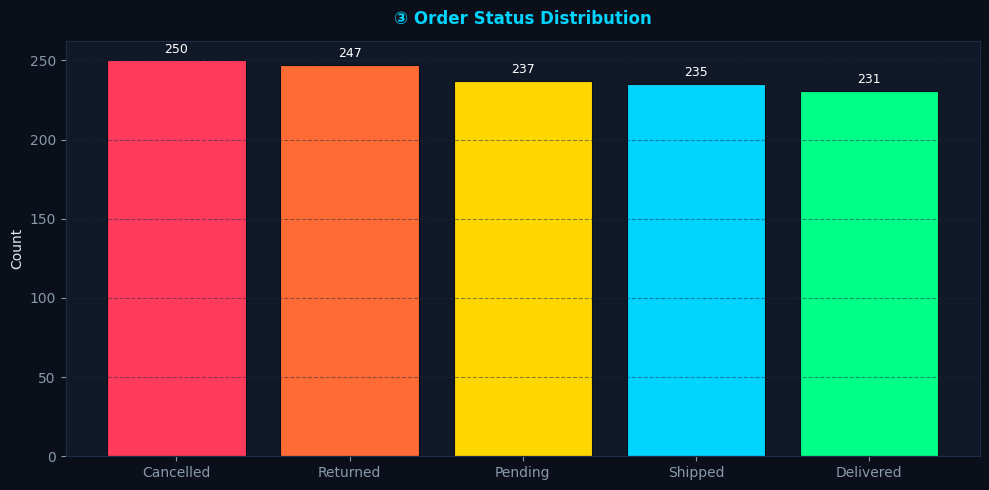

In [ ]:
fig, ax3 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax3, '③ Order Status Distribution')

status_counts = df['OrderStatus'].value_counts()
status_colors = {'Delivered': GREEN, 'Shipped': CYAN,
                 'Pending': YELLOW, 'Returned': ORANGE, 'Cancelled': RED}
bars = ax3.bar(status_counts.index,
               status_counts.values,
               color=[status_colors.get(s, CYAN) for s in status_counts.index],
               edgecolor='#0b0f1a', linewidth=0.8)
for bar, val in zip(bars, status_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=9, color='white')
ax3.set_ylabel('Count')

plt.tight_layout()
plt.show()

## ④ Total Revenue by Product

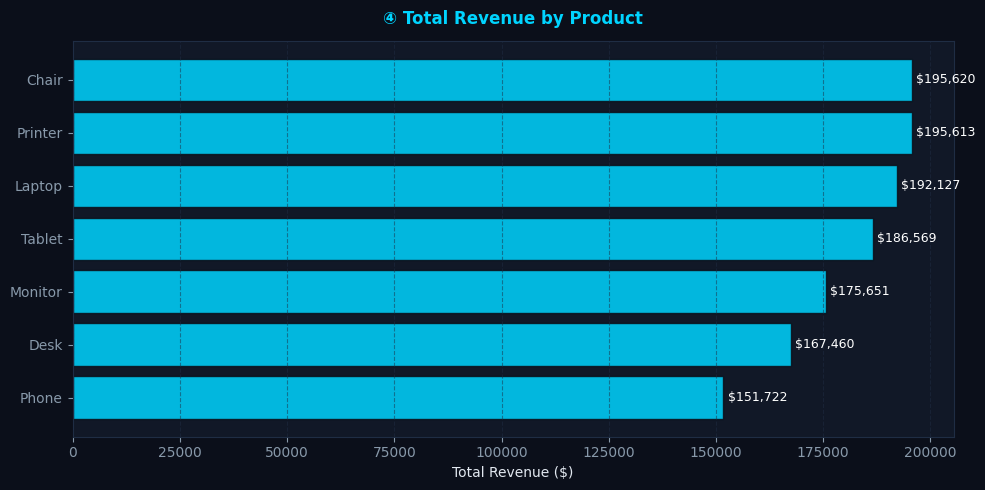

In [ ]:
fig, ax4 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax4, '④ Total Revenue by Product')
ax4.grid(axis='y', visible=False)

rev_sorted = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=True)
bars2 = ax4.barh(rev_sorted.index, rev_sorted.values,
                 color=CYAN, edgecolor='#0b0f1a', alpha=0.85)
for bar, val in zip(bars2, rev_sorted.values):
    ax4.text(val + 1000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9, color='white')
ax4.set_xlabel('Total Revenue ($)')
ax4.grid(axis='x', color='#1f2d44', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## ⑤ Referral Source

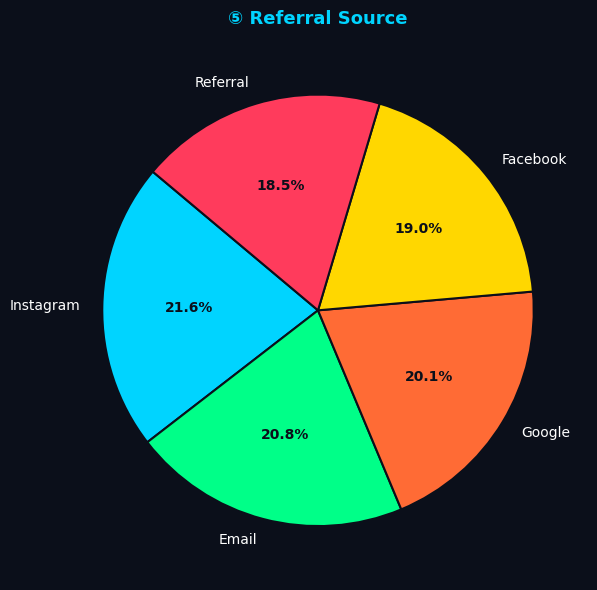

In [ ]:
fig, ax5 = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0b0f1a')
ax5.set_facecolor('#111827')
ax5.set_title('⑤ Referral Source', color=CYAN, fontsize=13, fontweight='bold', pad=12)

ref_counts = df['ReferralSource'].value_counts()
pie_colors = [CYAN, GREEN, ORANGE, YELLOW, RED]
wedges, texts, autotexts = ax5.pie(
    ref_counts.values,
    labels=ref_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    wedgeprops=dict(edgecolor='#0b0f1a', linewidth=1.5),
    textprops=dict(color='white', fontsize=10)
)
for at in autotexts:
    at.set_color('#0b0f1a')
    at.set_fontweight('bold')

plt.tight_layout()
plt.show()

## ⑥ Correlation Heatmap

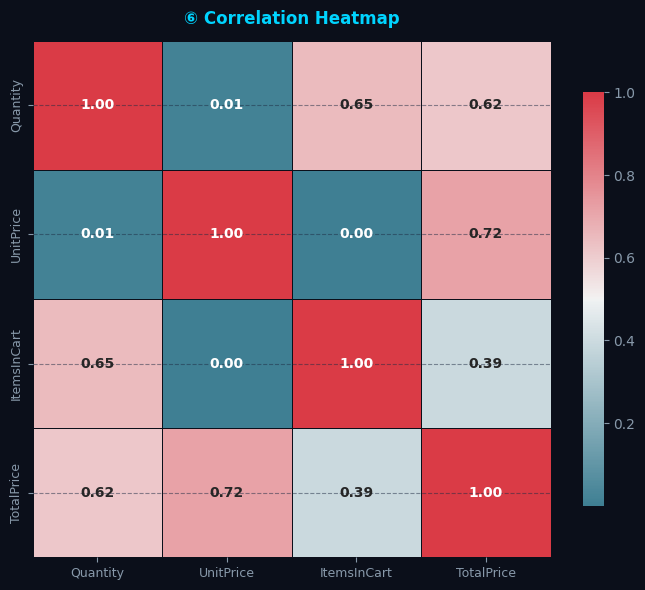

In [ ]:
fig, ax6 = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax6, '⑥ Correlation Heatmap')

corr_matrix = df[num_cols].corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, ax=ax6, annot=True, fmt='.2f',
            cmap=cmap, linewidths=0.5, linecolor='#0b0f1a',
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})
ax6.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## ⑦ Monthly Revenue Trend

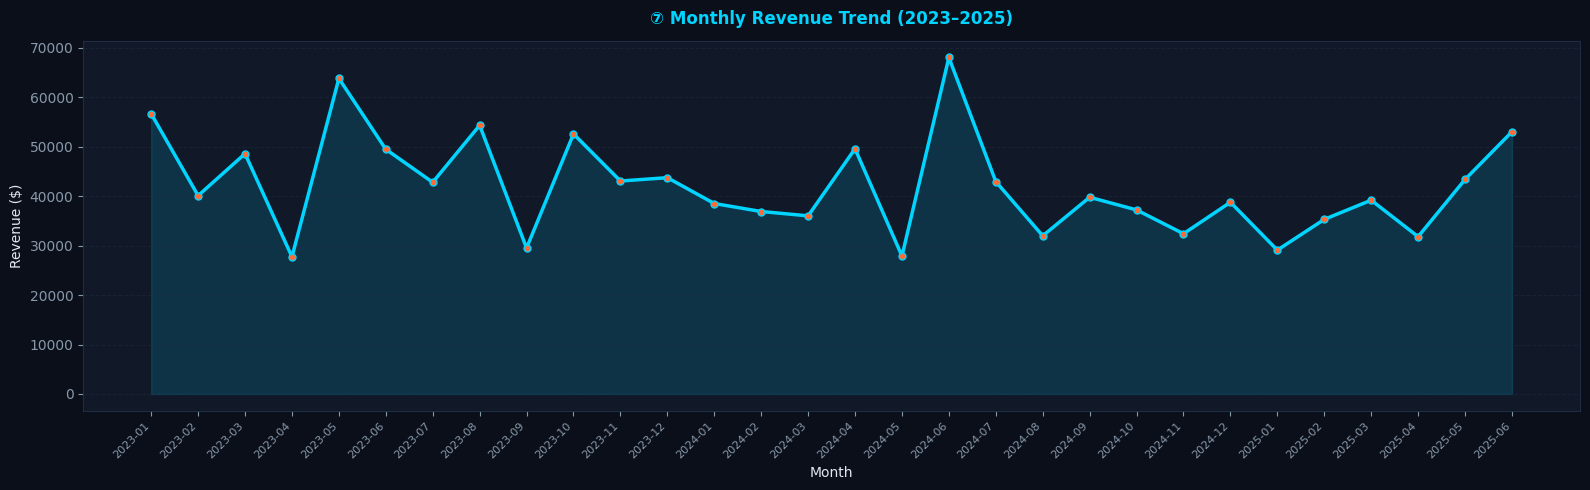

In [ ]:
fig, ax7 = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax7, '⑦ Monthly Revenue Trend (2023–2025)')

monthly = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

ax7.plot(monthly['YearMonth_str'], monthly['TotalPrice'],
         color=CYAN, lw=2.5, marker='o', markersize=5, markerfacecolor=ORANGE)
ax7.fill_between(monthly['YearMonth_str'], monthly['TotalPrice'],
                 alpha=0.15, color=CYAN)

step = max(1, len(monthly) // 18)
ax7.set_xticks(range(0, len(monthly), step))
ax7.set_xticklabels(monthly['YearMonth_str'].iloc[::step], rotation=45, ha='right', fontsize=8)
ax7.set_ylabel('Revenue ($)')
ax7.set_xlabel('Month')

plt.tight_layout()
plt.show()

# ⑧  Revenue by Product  (Bar Chart)


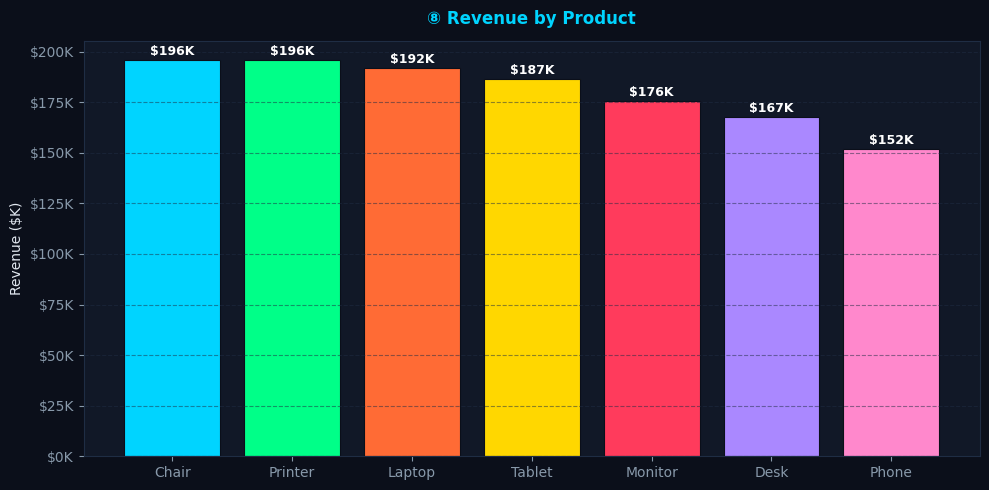

In [ ]:

fig, ax8 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax8, '⑧ Revenue by Product')

rev_product = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

bars = ax8.bar(
    rev_product.index,
    rev_product.values,
    color=BAR_COLORS[:len(rev_product)],
    edgecolor='#0b0f1a',
    linewidth=0.8
)

for bar, val in zip(bars, rev_product.values):
    ax8.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'${val/1000:.0f}K',
        ha='center', va='bottom',
        fontsize=9, color='white', fontweight='bold'
    )

ax8.set_ylabel('Revenue ($K)')
ax8.set_xlabel('')
ax8.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# ⑨  Payment Methods  (Pie Chart)


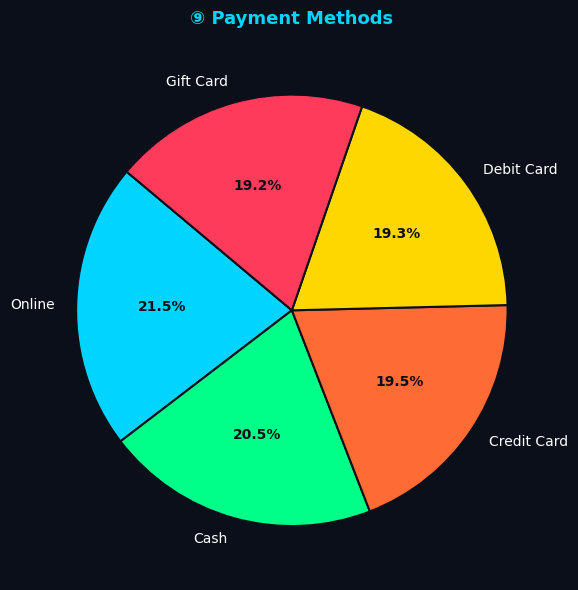

In [ ]:
fig, ax9 = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0b0f1a')
ax9.set_facecolor('#111827') # Set facecolor explicitly as styled_ax uses different settings
ax9.set_title('⑨ Payment Methods', color=CYAN, fontsize=13, fontweight='bold', pad=12)

payment_counts = df['PaymentMethod'].value_counts()
payment_colors = [CYAN, GREEN, ORANGE, YELLOW, RED] # Using existing colors for consistency
wedges, texts, autotexts = ax9.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=payment_colors,
    startangle=140,
    wedgeprops=dict(edgecolor='#0b0f1a', linewidth=1.5),
    textprops=dict(color='white', fontsize=10)
)
for at in autotexts:
    at.set_color('#0b0f1a') # Make percentage labels black for contrast
    at.set_fontweight('bold')

plt.tight_layout()
plt.show()

# ⑩  Revenue by Referral Source  (Bar Chart )


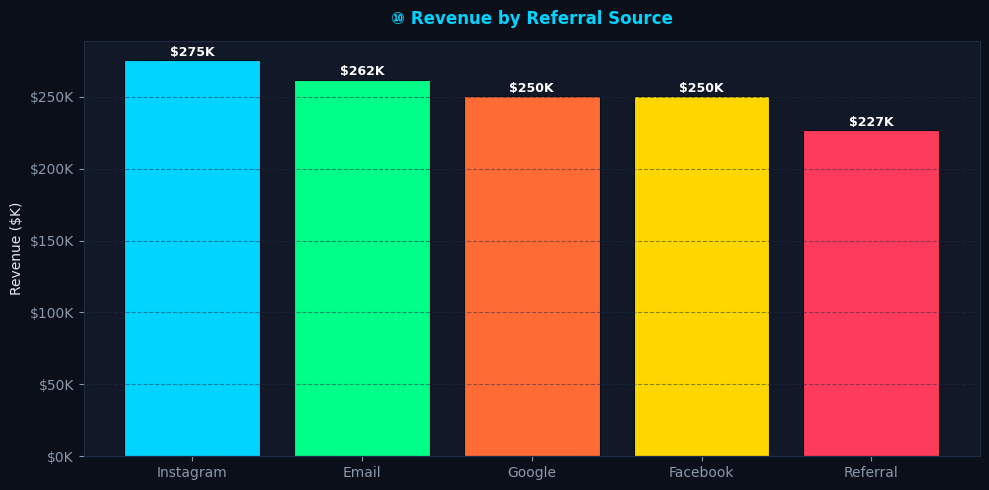

In [ ]:
fig, ax10 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax10, '⑩ Revenue by Referral Source')

rev_ref = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

bars = ax10.bar(
    rev_ref.index,
    rev_ref.values,
    color=BAR_COLORS[:len(rev_ref)],
    edgecolor='#0b0f1a',
    linewidth=0.8
)

for bar, val in zip(bars, rev_ref.values):
    ax10.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'${val/1000:.0f}K',
        ha='center', va='bottom',
        fontsize=9, color='white', fontweight='bold'
    )

ax10.set_ylabel('Revenue ($K)')
ax10.set_xlabel('')
ax10.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# ⑪  Avg Order Value by Product  (Bar Chart)


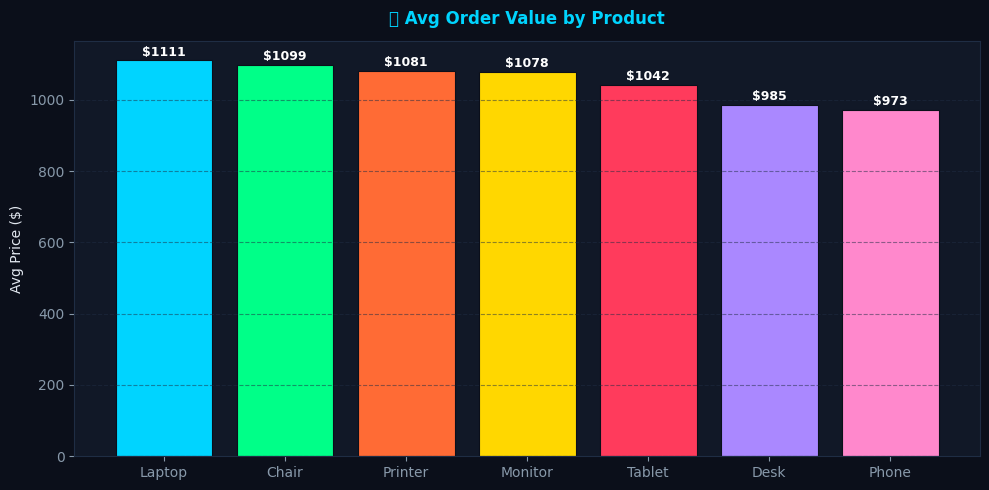

In [ ]:
fig, ax11 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax11, '⑪ Avg Order Value by Product')

avg_product = df.groupby('Product')['TotalPrice'].mean().sort_values(ascending=False)

bars = ax11.bar(
    avg_product.index,
    avg_product.values,
    color=BAR_COLORS[:len(avg_product)],
    edgecolor='#0b0f1a',
    linewidth=0.8
)

for bar, val in zip(bars, avg_product.values):
    ax11.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'${val:.0f}',
        ha='center', va='bottom',
        fontsize=9, color='white', fontweight='bold'
    )

ax11.set_ylabel('Avg Price ($)')
ax11.set_xlabel('')

plt.tight_layout()
plt.show()

# ⑫  Coupon Code Usage  (Bar Chart)


Text(0.5, 0, '')

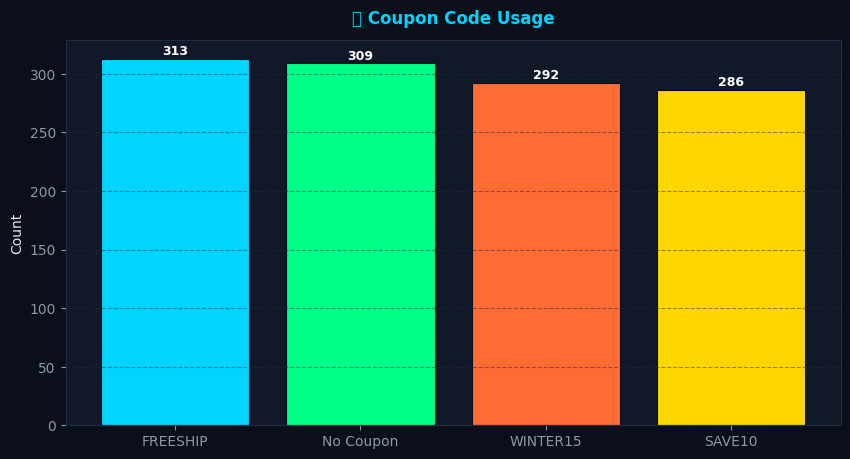

In [ ]:
fig, ax12 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0b0f1a')
styled_ax(ax12, '⑫ Coupon Code Usage')

coupon_counts = df['CouponCode'].value_counts()

bars = ax12.bar(
    coupon_counts.index,
    coupon_counts.values,
    color=BAR_COLORS[:len(coupon_counts)],
    edgecolor='#0b0f1a',
    linewidth=0.8
)

for bar, val in zip(bars, coupon_counts.values):
    ax12.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(val),
        ha='center', va='bottom',
        fontsize=9, color='white', fontweight='bold'
    )

ax12.set_ylabel('Count')
ax12.set_xlabel('')